# S&P 500 Equity+Options: Transaction Costs

This notebook stress-tests the leading eligible allocation lineage under two
execution-cost conventions. The headline curve charges a percentage of
traded notional. The companion curve uses a per-share commission plus a flat
dollar half-spread. Both are diagnostics computed on validation data.

**Learning objectives**

1. Carry one full-coverage allocation lineage into a controlled cost sweep.
2. Distinguish one-way cost per traded notional from round-trip cost.
3. Compare percentage and per-share cost conventions without treating their
   x-axes as interchangeable.
4. Read point estimates together with block-bootstrap uncertainty.

**Book reference:** Chapter 18, Sections 18.2-18.5.

**Prerequisites:** `15_portfolio_management` and its registry-backed
allocation results. Signals form after Friday's close and execute at the next
available open, normally Monday. The configured universe uses current S&P 500
constituents and therefore retains survivorship bias.

In [1]:
"""S&P 500 Equity+Options: transaction-cost sensitivity."""

import json
import sqlite3
import time
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

from case_studies.research import current_prediction_members, open_study
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    set_backtest_costs_bps,
    set_backtest_costs_per_share,
    strategy_view,
)
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    model_source,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_cost_grid_bps,
    get_cost_grid_half_spread_usd,
    get_per_share_commission,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
LABEL = ""
MAX_SYMBOLS = 0
TOP_N_COMBOS = None

### What is asked for, and what it resolves to

The parameters above are the request; the values this notebook runs on are resolved here under
different names, so a resolved value cannot overwrite the request that produced it. An injected
parameter wins; otherwise the case study's own declaration does.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY_ID)
TOP_N = (
    TOP_N_COMBOS
    if TOP_N_COMBOS is not None
    else get_top_n_predictions(CASE_STUDY_ID, "cost_sensitivity")
)
COST_LABEL = LABEL or bt_config.primary_label

COST_GRID_BPS = get_cost_grid_bps(CASE_STUDY_ID)
COST_GRID_HALF_SPREAD_USD = get_cost_grid_half_spread_usd(CASE_STUDY_ID)
PER_SHARE_COMMISSION = get_per_share_commission(CASE_STUDY_ID)
DEFAULT_ONE_WAY_BPS = bt_config.commission_bps + bt_config.slippage_bps

print(
    f"Case study: {CASE_STUDY_ID}; label: {COST_LABEL}; selected lineages: {TOP_N}; "
    f"configured one-way cost: {DEFAULT_ONE_WAY_BPS:.1f} bps"
)

_study = open_study(CASE_STUDY_ID, execution_tier="canonical")
CURRENT_MEMBERS = current_prediction_members(_study)

Case study: sp500_equity_option_analytics; label: fwd_ret_5d; selected lineages: 1; configured one-way cost: 6.5 bps


## 1. Advance the leading eligible strategy

The ranking compares the equal-weight baseline with the active alternative
allocators using validation Sharpe and maximum prediction coverage.
Historical rows from removed allocators cannot re-enter the cost stage.

In [4]:
active_allocators = {item["method"] for item in get_allocators(CASE_STUDY_ID)}
baseline_pool = resolve_best_backtest_runs(
    CASE_STUDY_ID,
    COST_LABEL,
    split="validation",
    stage="signal",
    top_n=9999,
    prediction_hashes=CURRENT_MEMBERS,
)
allocation_pool = resolve_best_backtest_runs(
    CASE_STUDY_ID,
    COST_LABEL,
    split="validation",
    stage="allocation",
    top_n=9999,
    prediction_hashes=CURRENT_MEMBERS,
)
candidate_pool = pl.concat([baseline_pool, allocation_pool], how="diagonal_relaxed").unique(
    "backtest_hash"
)
candidate_hashes = candidate_pool["prediction_hash"].unique().to_list()
if not candidate_hashes:
    raise RuntimeError("No full-coverage baseline or allocation candidates found")

Model labels come from prediction provenance rather than from free-form
strategy metadata.

In [5]:
with sqlite3.connect(REGISTRY_DB) as db:
    source_rows = db.execute(
        f"""
        SELECT p.prediction_hash, t.family, t.config_name
        FROM prediction_sets p
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.prediction_hash IN ({",".join("?" for _ in candidate_hashes)})
        """,
        candidate_hashes,
    ).fetchall()
source_by_hash = {
    prediction_hash: model_source(family, config_name)
    for prediction_hash, family, config_name in source_rows
}

The baseline is the equal-weight member of the candidate union. Alternative
allocation rows are eligible only when their method remains active in the
current case-study configuration.

In [6]:
eligible_rows = []
for row in candidate_pool.iter_rows(named=True):
    strategy = strategy_view(json.loads(row["spec_json"]))
    allocator = strategy.get("allocation", {}).get("method", "equal_weight")
    if allocator == "equal_weight" or allocator in active_allocators:
        eligible_rows.append(
            {
                **row,
                "source": source_by_hash[row["prediction_hash"]],
                "allocator": allocator,
                "top_k": strategy.get("signal", {}).get("top_k"),
            }
        )

if len(eligible_rows) < TOP_N:
    raise RuntimeError(f"Expected {TOP_N} eligible strategy lineages, found {len(eligible_rows)}")

top_combos = pl.DataFrame(eligible_rows).sort("sharpe", descending=True).head(TOP_N)
winner = top_combos.row(0, named=True)
print(
    f"Selected {winner['source']} with {winner['allocator']} allocation, "
    f"top-{winner['top_k']}, validation Sharpe {winner['sharpe']:.3f}"
)

Selected latent_factors/sae with mvo_ledoit_wolf allocation, top-5, validation Sharpe 1.600


The line above names the strategy this sweep stresses - its source, allocator, concentration and
allocation-stage Sharpe at the case study's configured one-way charge. That charge is per leg,
so a buy-and-sell round trip pays it twice, and the grid below is what says whether the result
depends on it.

In [7]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    COST_LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
print(
    f"Price support: {len(prices):,} rows across {prices['symbol'].n_unique()} historical symbols"
)

Price support: 505,922 rows across 614 historical symbols


## 2. Build the two cost surfaces

The percentage grid splits each one-way charge equally between commission
and slippage. The per-share grid fixes commission at the declared
`PER_SHARE_COMMISSION` and varies a uniform half-spread. It omits a per-order commission floor and does
not estimate name-specific spreads, so it is an exploratory convention rather
than a second production-cost estimate.

In [8]:
base_specs = []
for combo in top_combos.iter_rows(named=True):
    prediction_hash = combo["prediction_hash"]
    base_spec = ensure_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        json.loads(combo["spec_json"]),
        prices=prices,
        prediction_hash=prediction_hash,
        initial_cash=bt_config.initial_cash,
    )
    base_specs.append((combo, prediction_hash, base_spec))

The percentage-cost surface divides each one-way charge equally between
commission and slippage.

In [9]:
plans = []
for combo, prediction_hash, base_spec in base_specs:
    for cost_bps in COST_GRID_BPS:
        spec = set_backtest_costs_bps(
            clone_backtest_spec(base_spec),
            commission_bps=cost_bps / 2,
            slippage_bps=cost_bps / 2,
        )
        spec["chapter"] = "ch18"
        plans.append(
            {
                "regime": "bps",
                "cost_value": float(cost_bps),
                "source": combo["source"],
                "allocator": combo["allocator"],
                "prediction_hash": prediction_hash,
                "spec": spec,
                "backtest_hash": backtest_hash_from_parts(prediction_hash, spec),
            }
        )

The companion surface keeps the per-share commission fixed while varying a
flat dollar half-spread.

In [10]:
for combo, prediction_hash, base_spec in base_specs:
    for half_spread_usd in COST_GRID_HALF_SPREAD_USD:
        spec = set_backtest_costs_per_share(
            clone_backtest_spec(base_spec),
            per_share=PER_SHARE_COMMISSION,
            default_half_spread_usd=half_spread_usd,
        )
        spec["chapter"] = "ch18"
        plans.append(
            {
                "regime": "per_share",
                "cost_value": float(half_spread_usd),
                "source": combo["source"],
                "allocator": combo["allocator"],
                "prediction_hash": prediction_hash,
                "spec": spec,
                "backtest_hash": backtest_hash_from_parts(prediction_hash, spec),
            }
        )

Planned hashes make the publication replay idempotent: completed points are
read from the registry and only missing points are computed.

In [11]:
with sqlite3.connect(REGISTRY_DB) as db:
    existing_hashes = {row[0] for row in db.execute("SELECT backtest_hash FROM backtest_runs")}

cached = sum(plan["backtest_hash"] in existing_hashes for plan in plans)
print(f"Planned {len(plans)} cost backtests; {cached} already complete")

Planned 17 cost backtests; 17 already complete


A production run fails if any planned point fails. Cached hashes are reused;
the final publication replay should not mutate the registry.

In [12]:
prediction_cache = {}
failures = []
started = time.monotonic()

In [13]:
for index, plan in enumerate(plans, start=1):
    if plan["backtest_hash"] in existing_hashes:
        continue
    prediction_hash = plan["prediction_hash"]
    if prediction_hash not in prediction_cache:
        prediction_cache[prediction_hash] = read_predictions(CASE_STUDY_ID, prediction_hash)
    try:
        result = run_backtest(
            CASE_STUDY_ID,
            prediction_hash,
            plan["spec"],
            prices=prices,
            predictions=prediction_cache[prediction_hash],
            label=COST_LABEL,
            register=True,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
        )
        existing_hashes.add(plan["backtest_hash"])
        print(
            f"[{index}/{len(plans)}] {plan['regime']} cost={plan['cost_value']:.4g}: "
            f"Sharpe={result.metrics['sharpe']:.3f}",
            flush=True,
        )
    except Exception as exc:  # noqa: BLE001
        failures.append(f"{plan['backtest_hash']} {plan['regime']}: {exc}")

In [14]:
if failures:
    raise RuntimeError("Cost-sweep failures:\n" + "\n".join(failures))
print(f"Cost surfaces complete in {(time.monotonic() - started):.1f}s")

Cost surfaces complete in 0.0s


## 3. Compare the selected lineage

The query is keyed by the hashes planned above. Rows from other labels,
prediction lineages, removed allocators, and earlier sweeps cannot enter the
charts or takeaways.

In [15]:
plan_meta = pl.DataFrame(
    [
        {
            "backtest_hash": plan["backtest_hash"],
            "regime": plan["regime"],
            "cost_value": plan["cost_value"],
            "source": plan["source"],
            "allocator": plan["allocator"],
        }
        for plan in plans
    ]
)
placeholders = ",".join("?" for _ in plans)
with sqlite3.connect(REGISTRY_DB) as db:
    metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.stage, bm.sharpe, bm.sharpe_ci95_lo,
               bm.sharpe_ci95_hi, bm.max_drawdown, bm.num_trades
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({placeholders})
        """,
        connection=db,
        execute_options={"parameters": [plan["backtest_hash"] for plan in plans]},
    )

In [16]:
cost_results = plan_meta.join(metrics, on="backtest_hash", how="inner")
if len(cost_results) != len(plans):
    raise RuntimeError(f"Expected {len(plans)} cost rows, found {len(cost_results)}")
if cost_results.filter(pl.col("stage") != "cost_sensitivity").height:
    raise RuntimeError("A planned cost hash was registered under the wrong stage")
print(f"Loaded all {len(cost_results)} planned cost results")

Loaded all 17 planned cost results


**The shape of the decay is the finding, not any single point on it.** A curve that falls
smoothly across the grid says the result degrades with cost rather than depending on one cost
assumption being right; a curve with a cliff would say the opposite.

The bands below are conditional diagnostics for the selected lineage's return path. They do not
include the uncertainty introduced by selecting that lineage from the preceding signal and
allocation sweeps, so neither their bounds nor their zero crossings support a claim about the
selection procedure. The printout reports the crossings only to describe this path's sensitivity.

Conditional lower bound first reaches zero: 15 bps; point Sharpe first reaches zero: not within the grid; grid runs to 50 bps one-way


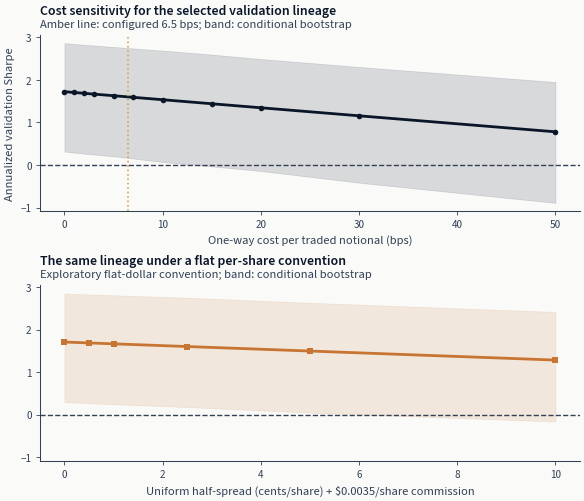

In [17]:
bps_results = cost_results.filter(pl.col("regime") == "bps").sort("cost_value")
per_share_results = cost_results.filter(pl.col("regime") == "per_share").sort("cost_value")


def first_zero_cost(column: str) -> float | None:
    """Lowest grid cost at which `column` reaches zero, or None if it never does."""
    reached = bps_results.filter(pl.col(column) <= 0)
    return reached["cost_value"].min() if reached.height else None


def _crossing(column: str) -> str:
    cost = first_zero_cost(column)
    return f"{cost:.0f} bps" if cost is not None else "not within the grid"


print(
    f"Conditional lower bound first reaches zero: {_crossing('sharpe_ci95_lo')}; "
    f"point Sharpe first reaches zero: {_crossing('sharpe')}; "
    f"grid runs to {bps_results['cost_value'].max():.0f} bps one-way"
)

fig, (ax_bps, ax_ps) = plt.subplots(
    2, 1, figsize=FIGSIZE["dual_v"], sharey=True, constrained_layout=True
)

ax_bps.plot(
    bps_results["cost_value"],
    bps_results["sharpe"],
    marker="o",
    color=COLORS["blue"],
    linewidth=2,
)
ax_bps.fill_between(
    bps_results["cost_value"],
    bps_results["sharpe_ci95_lo"],
    bps_results["sharpe_ci95_hi"],
    color=COLORS["blue"],
    alpha=0.14,
)
ax_bps.axhline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax_bps.axvline(DEFAULT_ONE_WAY_BPS, color=COLORS["amber"], linewidth=1.2, linestyle=":")
ax_bps.set_xlabel("One-way cost per traded notional (bps)")
ax_bps.set_ylabel("Annualized validation Sharpe")
add_message_title(
    ax_bps,
    "Cost sensitivity for the selected validation lineage",
    f"Amber line: configured {DEFAULT_ONE_WAY_BPS:.1f} bps; band: conditional bootstrap",
)

ax_ps.plot(
    per_share_results["cost_value"] * 100,
    per_share_results["sharpe"],
    marker="s",
    color=COLORS["copper"],
    linewidth=2,
)
ax_ps.fill_between(
    per_share_results["cost_value"] * 100,
    per_share_results["sharpe_ci95_lo"],
    per_share_results["sharpe_ci95_hi"],
    color=COLORS["copper"],
    alpha=0.14,
)
ax_ps.axhline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax_ps.set_xlabel(
    f"Uniform half-spread (cents/share) + ${PER_SHARE_COMMISSION:.4f}/share commission"
)
add_message_title(
    ax_ps,
    "The same lineage under a flat per-share convention",
    "Exploratory flat-dollar convention; band: conditional bootstrap",
)

fig.show()

## Key takeaways

1. **Cost selection is validation-only.** The eligible lineage is carried forward on validation
   evidence, and the holdout is not consulted anywhere in this notebook.

2. **The configured charge is one point on a curve, not the answer.** The vertical marker shows
   where the case study's declared one-way cost falls; a one-way charge is paid on both legs, so
   the round trip is twice it. What matters is not the Sharpe at that point but how steeply the
   curve falls either side of it, because the declared value is itself an assumption.

3. **The bootstrap band is conditional on the selected lineage.** It describes uncertainty in
   that return path at each cost, but it does not repeat the model and allocation selection.
   The curve is therefore a sensitivity diagnostic, not selection-adjusted evidence.

4. **The per-share convention is exploratory here and is not a second opinion.** A flat dollar
   half-spread applied to split-adjusted historical prices conflates split adjustment with
   realized friction, so it indicates sensitivity to a different cost shape rather than
   measuring this universe's actual execution cost. Name-level execution data is what would.

5. **A curve that stays positive across the grid does not establish out-of-sample efficacy.**
   It establishes that this validation result is not an artifact of one cost assumption, which
   is a narrower and more defensible claim.

**Next:** [`17_risk_management`](17_risk_management.ipynb) tests risk overlays on the same
eligible validation lineage. See Chapter 19 for the risk-control framework.